In [1]:
#%%
import math
import numpy as np

import inspect
import importlib

import scipy.interpolate
from scipy import stats

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
from matplotlib import colormaps


plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

from fft_architecture_exploration                        import *

path_to_save_svg = "Saved_Data"


rng = np.random.default_rng(42)

Importing IoT Node models
Importing IoT Node Energy models
Importing IoT Node Energy models
Importing Wireless communication packages
Importing Wireless communication packages
Importing custom modules data
Importing custom modules data
Importing Impact models
Importing Impact models
Importing IoT Node analysis models


In [2]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [3]:

N = 10000  # Monte Carlo samples



In [ ]:



our_Area           = np.array([0.119    , 0.123    , 0.129    , 0.141    ] )     
our_NFFT           = np.array([4096     , 4096     , 4096     , 4096     ] )                 
our_Latency_pFFT   = np.array([98423    , 49250    , 32883    , 24723    ] )                 
our_Energy_pFFT    = np.array([3388.9   , 1922.4   , 1434.1   , 1197.6    ] ) *1e-9 

our_Latency        = our_Latency_pFFT   
our_Energy         = our_Energy_pFFT       
our_Speedup        = baseline_latency / our_Latency                                
our_Power          = our_Energy       / our_Latency  

soA_name          =           [ "Liu 18"  ]       #"Pereira 22" , "Berta. 21 ", "Gonz. 24",  "Yang 21", "Mahdavi 19", "Shih 18", "Tian 19"  , "Paul 25"  ]         #"Deng 23"
soA_type          =           [ "Memory-b"]       #"Memory-b"   , "Memory-b"  , "Memory-b",  "Pipel." , "Pipel."    , "Pipel." , "Memory-b" , "Memory-b" ]         #"Pipel." 
soa_Area_FFT       = np.array([   1.67    ] )     #   0.185     , 0.185       , 1.08      ,  1.83     , 0.57        , 1.09     ,0.84        , 3.8        ] )       #0.48                        
soa_NFFT           = np.array([   4096    ] )     #   256       , 1024        , 1024      ,  2048     , 2048        , 2048     ,4096        , 4096       ] )       #1024                       
soa_Latency_pFFT   = np.array([   768     ] )     #   1025      , 3005        , 1320      ,  2048     , 1200        , 2048     ,5120        , 605        ] )       #245                         
soa_Energy_pFFT    = np.array([  240.98   ] )*1e-9#   187.23    , 1054.78     , 297.92    ,  260.31   , 600.82      , 541.60   ,599.04      , 495.67     ] ) *1e-9 #22.94      

soa_Area           = scale_area    (area= soa_Area_FFT,        nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)    
soa_Latency        = scale_latency (latency= soa_Latency_pFFT, nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)                      
soa_Energy         = soa_Energy_pFFT  *4096* (12/(soa_NFFT*np.log2(soa_NFFT)))     

soa_Speedup        = baseline_latency / soa_Latency                                
soa_Power          = soa_Energy       / soa_Latency  

In [5]:

alpha_studied = np.linspace(0.01, 1, 100,endpoint=False)

# ----------------------------------------------------------------------
# 2a. DERIVE RATIOS 
# ----------------------------------------------------------------------
para_theor_area_ratio    = (para_theor_Area+baseline_area)    / baseline_area
para_theor_power_ratio   = para_theor_Power   / baseline_power
para_theor_energy_ratio  = para_theor_Energy  / baseline_energy
para_theor_latency_ratio = para_theor_Latency / baseline_latency
para_theor_speedup_ratio = 1/(para_theor_latency_ratio)


para_theor_asi_res  = np.zeros((len(alpha_studied),len(paraLevel),3))
for i in range(para_theor_area_ratio.shape[0]):
    for j in range(3):
        para_theor_asi_res[:,i,j]  = asi_function (alpha=alpha_studied, area_ratio=para_theor_area_ratio[i,j], power_ratio=para_theor_power_ratio[i,j],print=False)

# ----------------------------------------------------------------------
pipe_theor_area_ratio    = (pipe_theor_Area+baseline_area)    / baseline_area
pipe_theor_power_ratio   = pipe_theor_Power   / baseline_power
pipe_theor_energy_ratio  = pipe_theor_Energy  / baseline_energy
pipe_theor_latency_ratio = pipe_theor_Latency / baseline_latency
pipe_theor_speedup_ratio = 1/(pipe_theor_latency_ratio)

pipe_theor_asi_res  = np.zeros((len(alpha_studied),len(pipeLevel),3))
for i in range(pipe_theor_area_ratio.shape[0]):
    for j in range(3):
        pipe_theor_asi_res[:,i,j]  = asi_function (alpha=alpha_studied, area_ratio=pipe_theor_area_ratio[i,j], power_ratio=pipe_theor_power_ratio[i,j],print=False)


# ----------------------------------------------------------------------
pipePara_theor_area_ratio    = (pipePara_theor_Area+baseline_area)    / baseline_area
pipePara_theor_power_ratio   = pipePara_theor_Power   / baseline_power
pipePara_theor_energy_ratio  = pipePara_theor_Energy  / baseline_energy
pipePara_theor_latency_ratio = pipePara_theor_Latency / baseline_latency
pipePara_theor_speedup_ratio = 1/(pipePara_theor_latency_ratio)

pipePara_theor_asi_res  = np.zeros((len(alpha_studied),len(paraLevel),3))
for i in range(pipePara_theor_area_ratio.shape[0]):
    for j in range(3):
        pipePara_theor_asi_res[:,i,j]  = asi_function (alpha=alpha_studied, area_ratio=pipePara_theor_area_ratio[i,j], power_ratio=pipePara_theor_power_ratio[i,j],print=False)

# ----------------------------------------------------------------------
our_area_ratio    = (our_Area+baseline_area)    / baseline_area
our_power_ratio   = our_Power   / baseline_power
our_energy_ratio  = our_Energy  / baseline_energy
our_latency_ratio = our_Latency / baseline_latency
our_speedup_ratio = 1/(our_latency_ratio)

our_asi_res  = np.zeros((len(alpha_studied),len(our_area_ratio)))
our_ncf_res  = np.zeros((len(alpha_studied),len(our_area_ratio),2))
for i in range(our_area_ratio.shape[0]):
    print(f"THEOR {i}: area_ratio={our_area_ratio[i]:.2f}, area={our_Area[i]:.4f},  power_ratio={our_power_ratio[i]:.2f}, energy_ratio={our_energy_ratio[i]:.2f}, speedup={our_speedup_ratio[i]:.2f}")
    our_asi_res[:,i]  = asi_function (alpha=alpha_studied, area_ratio=our_area_ratio[i], power_ratio=our_power_ratio[i],print=False)
    our_ncf_res[:,i,0]= (our_area_ratio[i]* (alpha_studied)) +  (our_energy_ratio[i]* (1-alpha_studied))
    our_ncf_res[:,i,1]= (our_area_ratio[i]* (alpha_studied)) +  (our_power_ratio[i] * (1-alpha_studied))

# ----------------------------------------------------------------------
soa_area_ratio    = (soa_Area+baseline_area)    / baseline_area
soa_power_ratio   = soa_Power   / baseline_power
soa_energy_ratio  = soa_Energy  / baseline_energy
soa_latency_ratio = soa_Latency / baseline_latency
soa_speedup_ratio = 1/(soa_latency_ratio)

soa_asi_res  = np.zeros((len(alpha_studied),len(soa_area_ratio)))
soa_ncf_res  = np.zeros((len(alpha_studied),len(soa_area_ratio),2))
for i in range(soa_area_ratio.shape[0]):
    print(f"SOA {i}: area_ratio={soa_area_ratio[i]:.2f},area={soa_Area[i]:.4f}, power_ratio={soa_power_ratio[i]:.2f}, energy_ratio={soa_energy_ratio[i]:.2f}, speedup={soa_speedup_ratio[i]:.2f}")
    soa_asi_res[:,i]  = asi_function (alpha=alpha_studied, area_ratio=soa_area_ratio[i], power_ratio=soa_power_ratio[i],print=False)
    soa_ncf_res[:,i,0]= (soa_area_ratio[i]* (alpha_studied)) +  (soa_energy_ratio[i]* (1-alpha_studied))
    soa_ncf_res[:,i,1]= (soa_area_ratio[i]* (alpha_studied)) +  (soa_power_ratio[i] * (1-alpha_studied))

ValueError: operands could not be broadcast together with shapes (100,) (3,) 

Text(0.5, 1.0, 'State-of-the-art KPIs\n (Marker size ∝ Area)')

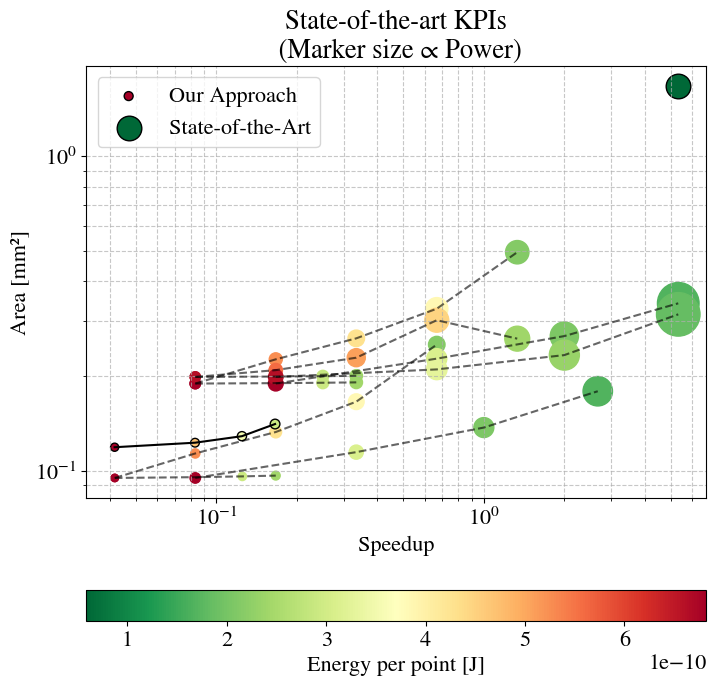

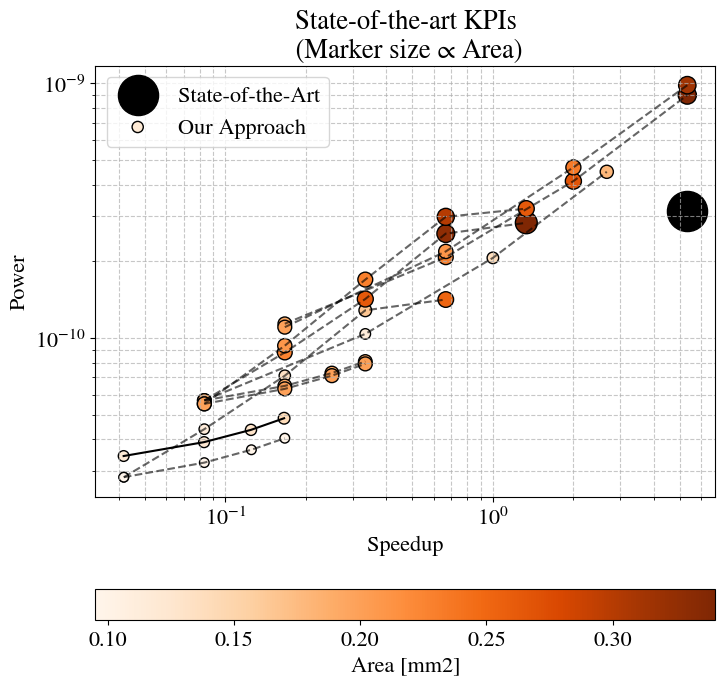

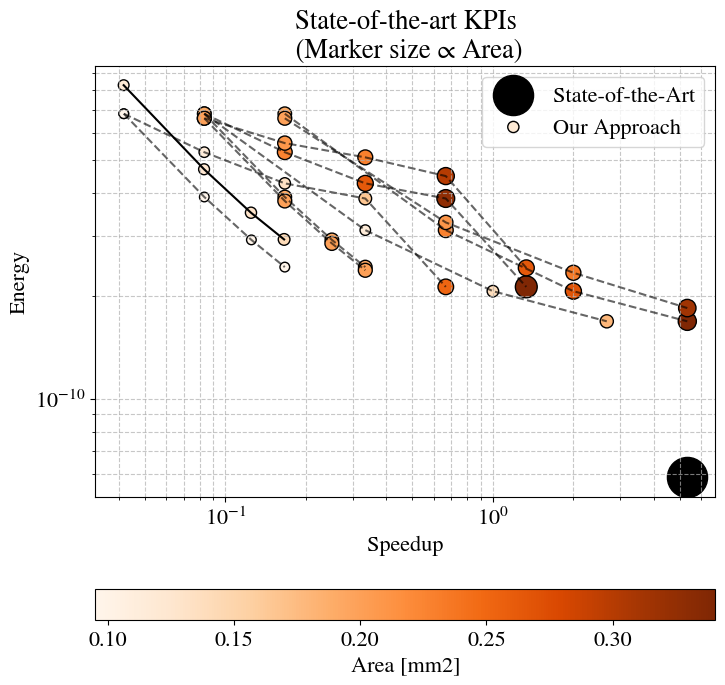

In [927]:
fig, ax = plt.subplots(1,1, figsize=(8, 8))

for i in range(3):
    sc = ax.scatter(    1/para_theor_Latency[:,i],     para_theor_Area[:,i], c=     para_theor_Energy[:,i],  cmap='RdYlGn_r', s=    para_theor_Power[:,i]*4e12, vmin =np.min(soa_Energy),vmax = np.max(pipe_theor_Energy), alpha=1, marker = '.')
    sc = ax.scatter(    1/pipe_theor_Latency[:,i],     pipe_theor_Area[:,i], c=     pipe_theor_Energy[:,i],  cmap='RdYlGn_r', s=    pipe_theor_Power[:,i]*4e12, vmin =np.min(soa_Energy),vmax = np.max(pipe_theor_Energy), alpha=1, marker = '.')
    sc = ax.scatter(1/pipePara_theor_Latency[:,i], pipePara_theor_Area[:,i], c= pipePara_theor_Energy[:,i],  cmap='RdYlGn_r', s=pipePara_theor_Power[:,i]*4e12, vmin =np.min(soa_Energy),vmax = np.max(pipe_theor_Energy), alpha=1, marker = '.')
    
    ax.plot(    1/para_theor_Latency[:,i],     para_theor_Area[:,i], color = 'black', alpha=0.6, linestyle ='--')
    ax.plot(    1/pipe_theor_Latency[:,i],     pipe_theor_Area[:,i], color = 'black', alpha=0.6, linestyle ='--')
    ax.plot(1/pipePara_theor_Latency[:,i], pipePara_theor_Area[:,i], color = 'black', alpha=0.6, linestyle ='--')

sc = ax.scatter(1/our_Latency  , our_Area  , c= our_Energy  ,  cmap='RdYlGn_r', s=our_Power*4e12, vmin =np.min(soa_Energy),vmax = np.max(pipe_theor_Energy), alpha=1, marker = '.', edgecolors="black", label="Our Approach")
sc = ax.scatter(1/soa_Latency  , soa_Area  , c= soa_Energy  ,  cmap='RdYlGn_r', s=soa_Power*4e12, vmin =np.min(soa_Energy),vmax = np.max(pipe_theor_Energy), alpha=1, marker = '.', edgecolors="black", label="State-of-the-Art")
ax.plot(1/our_Latency    , our_Area  , color = "black")

fig.colorbar(sc, ax=ax, label='Energy per point [J]', location='bottom')
ax.legend()

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Area [mm²]')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n (Marker size ∝ Power)')

######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(8, 8))

for i in range(3):
    sc = ax.scatter(    1/para_theor_Latency[:,i],     para_theor_Power[:,i], c=     para_theor_Area[:,i],  cmap='Oranges', s=    para_theor_Area[:,i]*2e3 ,vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), edgecolors="black", alpha=1, marker = '.')
    sc = ax.scatter(    1/pipe_theor_Latency[:,i],     pipe_theor_Power[:,i], c=     pipe_theor_Area[:,i],  cmap='Oranges', s=    pipe_theor_Area[:,i]*2e3 ,vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), edgecolors="black", alpha=1, marker = '.')
    sc = ax.scatter(1/pipePara_theor_Latency[:,i], pipePara_theor_Power[:,i], c= pipePara_theor_Area[:,i],  cmap='Oranges', s=pipePara_theor_Area[:,i]*2e3 ,vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), edgecolors="black", alpha=1, marker = '.')
    
    ax.plot(    1/para_theor_Latency[:,i],     para_theor_Power[:,i], color = 'black', alpha=0.6, linestyle ='--')
    ax.plot(    1/pipe_theor_Latency[:,i],     pipe_theor_Power[:,i], color = 'black', alpha=0.6, linestyle ='--')
    ax.plot(1/pipePara_theor_Latency[:,i], pipePara_theor_Power[:,i], color = 'black', alpha=0.6, linestyle ='--')

ax.plot(1/our_Latency    , our_Power  , color = "black")
sc = ax.scatter(1/soa_Latency  , soa_Power  , c= "black",                                                                                      s=soa_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="State-of-the-Art")
sc = ax.scatter(1/our_Latency  , our_Power  , c= our_Area  ,  cmap='Oranges',vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), s=our_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="Our Approach")

fig.colorbar(sc, ax=ax, label='Area [mm2]', location='bottom')
ax.legend()

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Power')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n (Marker size ∝ Area)')


######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(8, 8))

for i in range(3):
    sc = ax.scatter(    1/para_theor_Latency[:,i],     para_theor_Energy[:,i], c=     para_theor_Area[:,i],  cmap='Oranges', s=    para_theor_Area[:,i]*2e3,vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), edgecolors="black", alpha=1, marker = '.')
    sc = ax.scatter(    1/pipe_theor_Latency[:,i],     pipe_theor_Energy[:,i], c=     pipe_theor_Area[:,i],  cmap='Oranges', s=    pipe_theor_Area[:,i]*2e3,vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), edgecolors="black", alpha=1, marker = '.')
    sc = ax.scatter(1/pipePara_theor_Latency[:,i], pipePara_theor_Energy[:,i], c= pipePara_theor_Area[:,i],  cmap='Oranges', s=pipePara_theor_Area[:,i]*2e3,vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), edgecolors="black", alpha=1, marker = '.')
    
    ax.plot(    1/para_theor_Latency[:,i],     para_theor_Energy[:,i], color = 'black', alpha=0.6, linestyle ='--')
    ax.plot(    1/pipe_theor_Latency[:,i],     pipe_theor_Energy[:,i], color = 'black', alpha=0.6, linestyle ='--')
    ax.plot(1/pipePara_theor_Latency[:,i], pipePara_theor_Energy[:,i], color = 'black', alpha=0.6, linestyle ='--')

ax.plot(1/our_Latency    , our_Energy  , color = "black")
sc = ax.scatter(1/soa_Latency  , soa_Energy  , c= "black",                                                                                      s=soa_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="State-of-the-Art")
sc = ax.scatter(1/our_Latency  , our_Energy  , c= our_Area  ,  cmap='Oranges',vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), s=our_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="Our Approach")

fig.colorbar(sc, ax=ax, label='Area [mm2]', location='bottom')

ax.legend()

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Energy')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n (Marker size ∝ Area)')

C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_35160\666584784.py:24: UserWarning:

Attempt to set non-positive xlim on a log-scaled axis will be ignored.



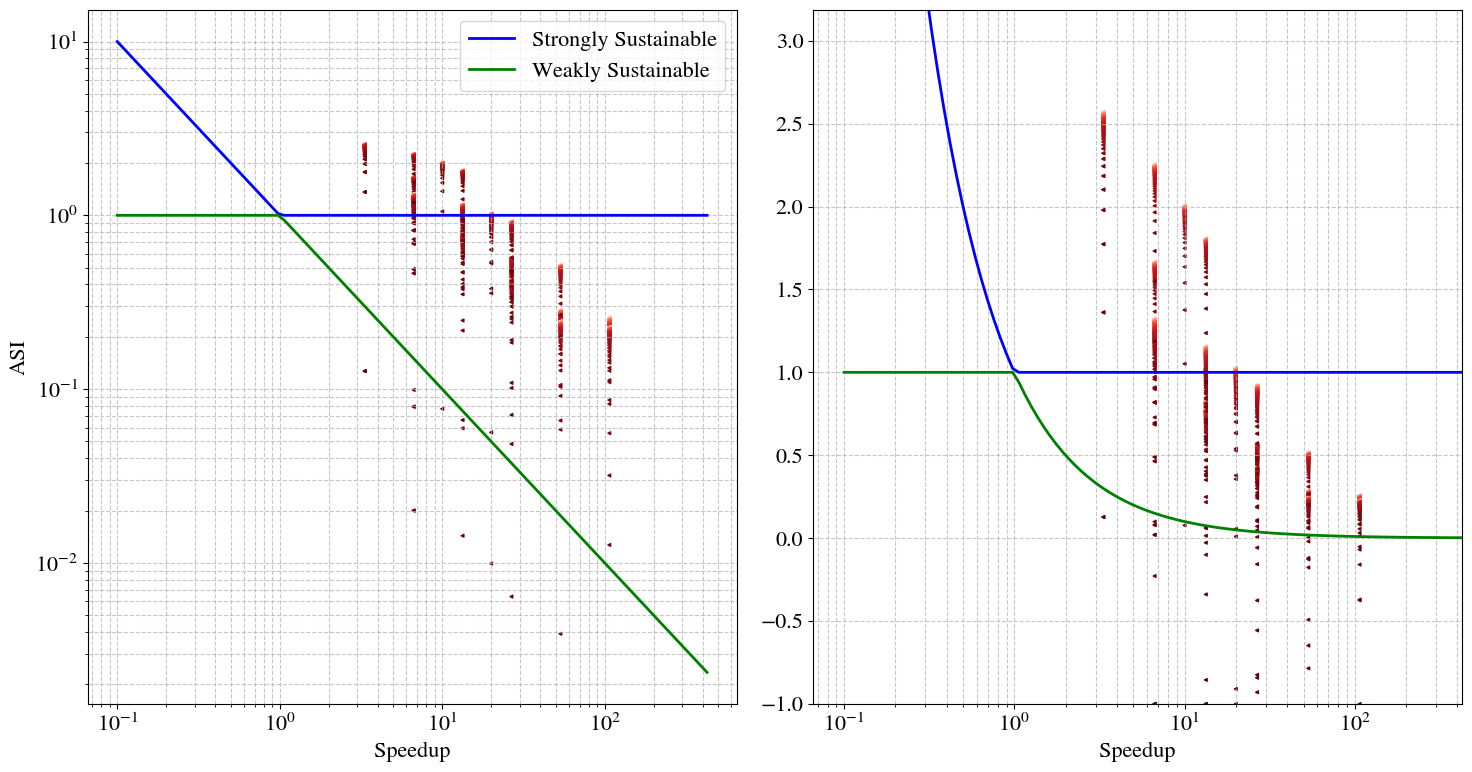

In [ ]:
# ASI Framework separations
speedup_space = np.logspace(-1, np.log10(np.max(soa_speedup_ratio)), 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1


# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,2,figsize=(15, 8))
ax[0].set_ylabel('ASI')
ax[0].loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax[0].loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')
ax[1].plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax[1].plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

ax[1].set_xscale('log')

ax[0].set_xlabel('Speedup')
ax[1].set_xlabel('Speedup')
ax[1].set_ylim([-1,np.max(our_asi_res)*1.5])
ax[1].set_xlim([0,np.max(soa_speedup_ratio)])

ax[0].grid(True, which='both', linestyle='--', alpha=0.7)
ax[1].grid(True, which='both', linestyle='--', alpha=0.7)

## Add our accelerator
#for i in range(soa_area_ratio.shape[0]):
#    p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[i],   np.maximum(soa_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4)
#    p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[i],   np.maximum(soa_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4)
#fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')
#
## Add our accelerator
#for i in range(our_area_ratio.shape[0]):
#    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='s')
#    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='s')
#
for i in range(para_theor_area_ratio.shape[0]):
    for j in range(3):
        p = ax[0].scatter(np.ones(len(alpha_studied))*para_theor_speedup_ratio[i,j],   np.maximum(para_theor_asi_res[:,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')
        p = ax[1].scatter(np.ones(len(alpha_studied))*para_theor_speedup_ratio[i,j],   np.maximum(para_theor_asi_res[:,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')
for i in range(pipe_theor_area_ratio.shape[0]):
    for j in range(3):
        p = ax[0].scatter(np.ones(len(alpha_studied))*pipe_theor_speedup_ratio[i,j],   np.maximum(pipe_theor_asi_res[:,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')
        p = ax[1].scatter(np.ones(len(alpha_studied))*pipe_theor_speedup_ratio[i,j],   np.maximum(pipe_theor_asi_res[:,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')
for i in range(pipePara_theor_area_ratio.shape[0]):
    for j in range(3):
        p = ax[0].scatter(np.ones(len(alpha_studied))*pipePara_theor_speedup_ratio[i,j],   np.maximum(pipePara_theor_asi_res[:,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')
        p = ax[1].scatter(np.ones(len(alpha_studied))*pipePara_theor_speedup_ratio[i,j],   np.maximum(pipePara_theor_asi_res[:,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')

ax[0].legend()
# Add legend
fig.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


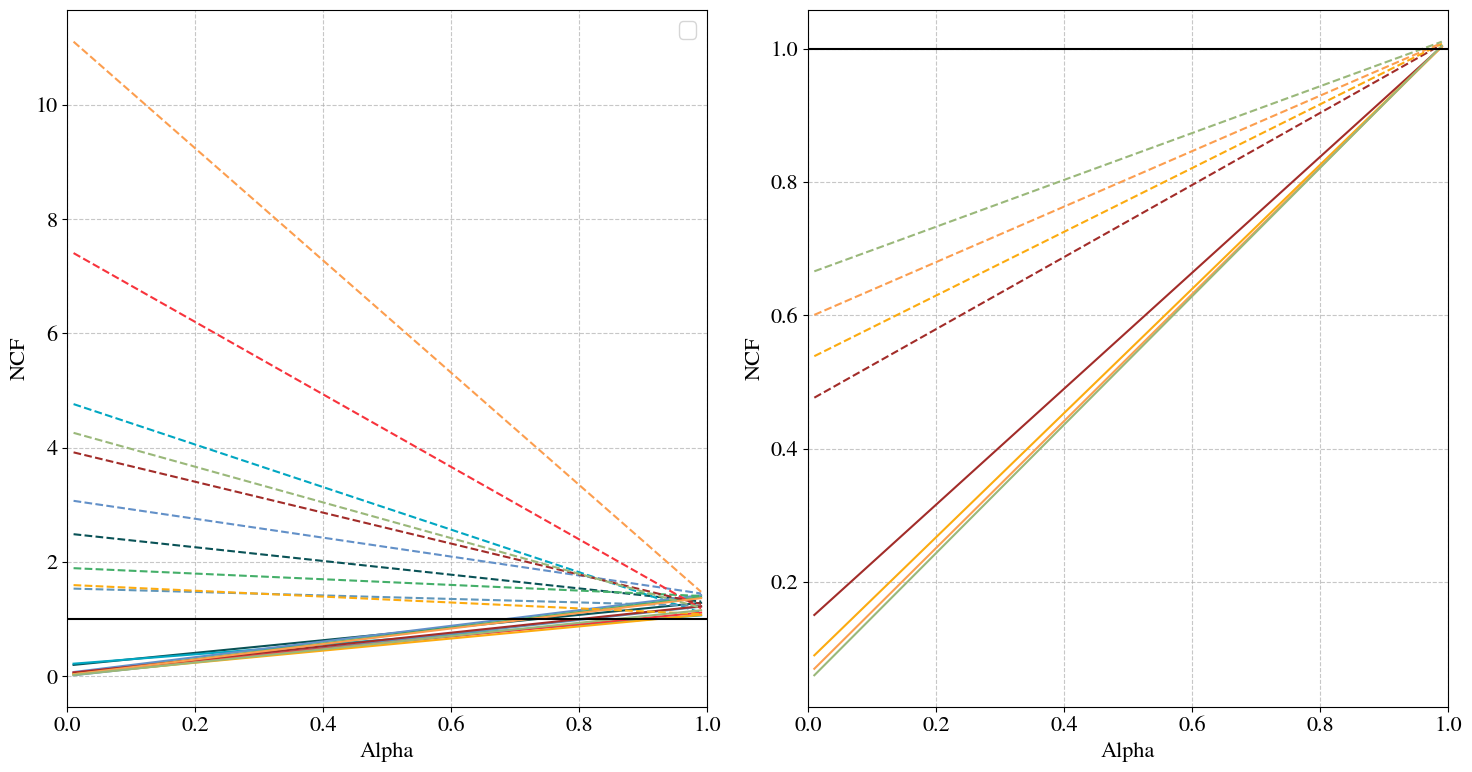

In [781]:
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,2,figsize=(15, 8))


ax[0].set_xlabel('ALpha')
ax[1].set_xlabel('ALpha')

ax[0].grid(True, which='both', linestyle='--', alpha=0.7)
ax[1].grid(True, which='both', linestyle='--', alpha=0.7)

# Add our accelerator
for i in range(soa_area_ratio.shape[0]):
    p = ax[0].plot(alpha_studied,   soa_ncf_res[:,i,0],   color = listColor[i] , linestyle ='-')
    p = ax[0].plot(alpha_studied,   soa_ncf_res[:,i,1],   color = listColor[i] , linestyle ='--')


for i in range(our_area_ratio.shape[0]):
    p = ax[1].plot(alpha_studied,   our_ncf_res[:,i,0],   color = listColor[i+6] , linestyle ='-')
    p = ax[1].plot(alpha_studied,   our_ncf_res[:,i,1],   color = listColor[i+6] , linestyle ='--')

ax[0].hlines(y=1,xmin = 0, xmax=1, color= "black")
ax[1].hlines(y=1,xmin = 0, xmax=1, color= "black")

ax[0].set_xlim([0,1])
ax[1].set_xlim([0,1])

ax[0].set_xlabel("Alpha")
ax[1].set_xlabel("Alpha")
ax[0].set_ylabel("NCF")
ax[1].set_ylabel("NCF")
ax[0].legend()
# Add legend
fig.tight_layout()
plt.show()


In [782]:
ref_point_soa = soA_name.index("Liu 18")

ref_acc_area          =  soa_Area         [ref_point_soa] #0.2
ref_acc_speedup       =  soa_speedup_ratio[ref_point_soa] #10
ref_acc_energy_ratio  =  soa_energy_ratio [ref_point_soa] #10

print(f"Ref. Point area         : {ref_acc_area:.2f}")
print(f"Ref. Point Speedup      : {ref_acc_speedup:.2f}")
print(f"Ref. Point Energy Ratio : {ref_acc_energy_ratio:.2e}")

Ref. Point area         : 1.67
Ref. Point Speedup      : 426.67
Ref. Point Energy Ratio : 1.01e-02


In [783]:
# Speedup factor for the accelerated task (accelerator time vs. baseline
# software-only time). Used to derive the *active-time* energy reduction.
#speedup = rng.triangular(left=5, mode=13, right=25, size=N)
speedup = 10**rng.uniform(low=0.5, high=2.7, size=N)
#speedup = rng.uniform(low=10, high=20, size=N)


# Area overhead of the accelerator, as a fraction of baseline MCU area.
# e.g. 0.15 means the accelerator adds 15% area on top of the baseline MCU.
#area_overhead = rng.triangular(left=0.01, mode=1, right=10, size=N)
#area_overhead = 10**rng.uniform(low=-1, high=1, size=N)
#area_overhead = rng.uniform(low=0.01, high=1, size=N)

deterministic_area = (speedup * ref_acc_area / ref_acc_speedup)  
area_overhead = deterministic_area* rng.uniform(low=0.3, high=1, size=N)

# Additional energy efficiency gain of the accelerator's datapath itself,
# beyond what raw speedup alone would give 
#energy_ratio = 1 # /rng.triangular(left=5, mode=15, right=30, size=N)
#energy_ratio = (1/ (10**rng.uniform(low=0.8, high=1.5, size=N))) 

#energy_ratio = (1/ (10**rng.uniform(low=0.8, high=1.5, size=N))) / ((area_overhead  / ref_acc_area)**rng.uniform(low=0, high=0.5, size=N))
energy_ratio = ref_acc_energy_ratio * rng.uniform(low=0.99, high=1.01, size=N)

power_ratio = (energy_ratio) * speedup

# alpha: embodied-vs-operational weighting. Default: fully uncertain
# (uninformed) over [0,1]. If you have a specific deployment scenario
# (duty cycle, lifetime, grid carbon intensity) narrow this -- e.g.
# rng.beta(2, 5) skews toward operational-dominated (low alpha) for an
# always-on high-duty-cycle edge device, or rng.beta(5, 2) for a
# rarely-active, short-lifetime, embodied-dominated device.
alpha = rng.uniform(low=0.001, high=0.99, size=N)

print(f"Baseline area    : {baseline_area:.2f}")
print(f"Baseline power   : {baseline_power:.2e}")
print(f"Baseline energy  : {baseline_energy:.2e}")
print(f"Baseline latency : {baseline_latency:.2f}")

Baseline area    : 10.00
Baseline power   : 7.31e-11
Baseline energy  : 5.85e-09
Baseline latency : 80.00


In [784]:
# ----------------------------------------------------------------------
# 1a. NEW DESIGN PERF
# ----------------------------------------------------------------------

new_area = baseline_area + area_overhead

new_power = baseline_power * power_ratio

new_energy= baseline_energy * energy_ratio
print(new_energy)

new_latency = baseline_latency / speedup

print(f"New area    : {new_area[0]:.2f}")
print(f"New power   : {new_power[0]:.2e}")
print(f"New energy  : {new_energy[0]:.2e}")
print(f"New latency : {new_latency[0]:.2f}")
# ----------------------------------------------------------------------
# 2a. DERIVE RATIOS 
# ----------------------------------------------------------------------

area_ratio    = new_area / baseline_area
power_ratio   = new_power / baseline_power
energy_ratio  = new_energy / baseline_energy
latency_ratio = new_latency / baseline_latency

# ----------------------------------------------------------------------
# 2b. DERIVE DELTAS 
# ----------------------------------------------------------------------

area_delta    = new_area    - baseline_area
power_delta   = new_power   - baseline_power
energy_delta  = new_energy  - baseline_energy
latency_delta = new_latency - baseline_latency

# ----------------------------------------------------------------------
# 2c. DERIVE RELATIVE DELTAS 
# ----------------------------------------------------------------------

area_relDelta    = (new_area    - baseline_area    ) /baseline_area
power_relDelta   = (new_power   - baseline_power   ) /baseline_power
energy_relDelta  = (new_energy  - baseline_energy  ) /baseline_energy
latency_relDelta = (new_latency - baseline_latency ) /baseline_latency


[5.91163155e-11 5.94164035e-11 5.82928941e-11 ... 5.89514934e-11
 5.93893451e-11 5.84245909e-11]
New area    : 10.50
New power   : 1.18e-10
New energy  : 5.91e-11
New latency : 0.50


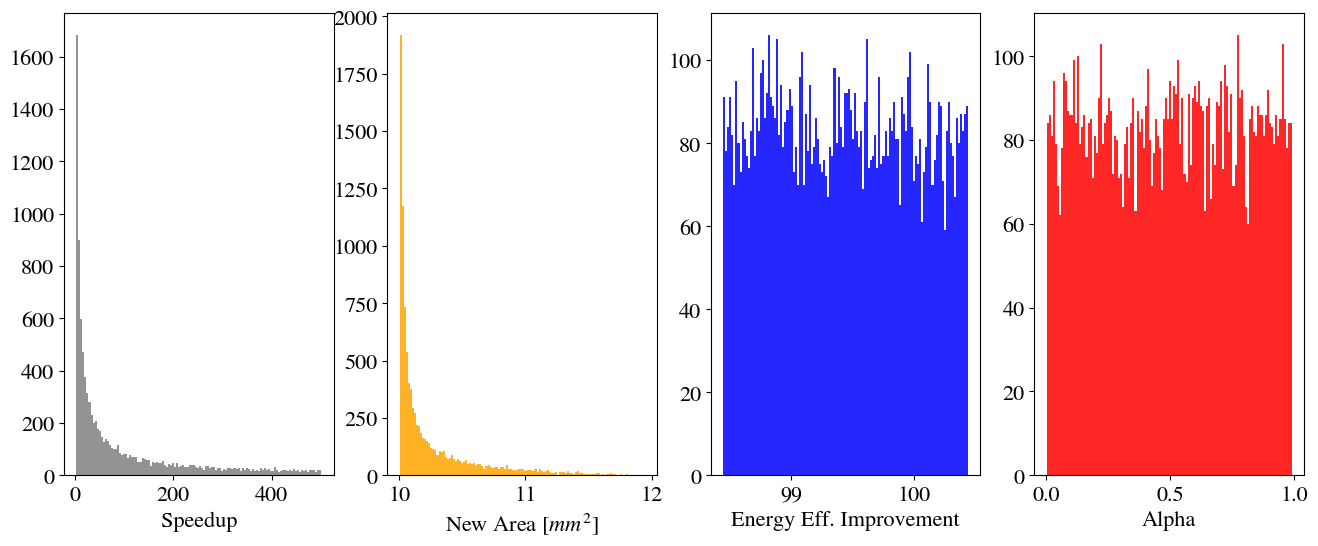

In [785]:

fig, ax = plt.subplots(1,4, figsize=(16,6))

ax[0].hist(speedup, bins=120, color='Gray', alpha=0.85, edgecolor='none')
ax[0].set_xlabel('Speedup')
ax[1].hist(new_area, bins=120, color='Orange', alpha=0.85, edgecolor='none')
ax[1].set_xlabel('New Area [$mm^2$]')
ax[2].hist(1/energy_ratio, bins=120, color='Blue', alpha=0.85, edgecolor='none')
ax[2].set_xlabel('Energy Eff. Improvement')
ax[3].hist(alpha, bins=120, color='Red', alpha=0.85, edgecolor='none')
ax[3].set_xlabel('Alpha')

plt.show()

Text(0.5, 1.0, 'Outcome across design space\n(color = sustainability outcome)')

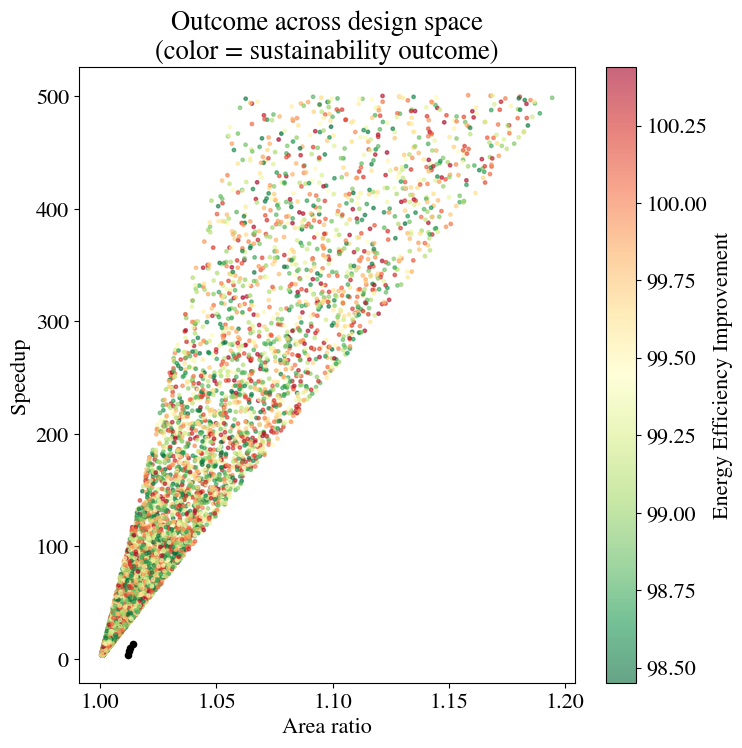

In [786]:

fig, axes = plt.subplots(1,1, figsize=(8, 8))

ax = axes #axes[1, 0]
sc = ax.scatter(area_ratio, speedup, c=1/energy_ratio,
                 cmap='RdYlGn_r', s=6, vmin=np.min(1/energy_ratio), vmax=np.max(1/energy_ratio), alpha=0.6)

plt.colorbar(sc, ax=ax, label='Energy Efficiency Improvement')

for i in range(our_Area.shape[0]):
    ax.scatter (our_area_ratio[i], our_Speedup[i], s = 20, c ='black')

ax.set_xlabel('Area ratio')
ax.set_ylabel('Speedup')
ax.set_title('Outcome across design space\n(color = sustainability outcome)')



In [787]:
# ----------------------------------------------------------------------
# 3. XASI METRIC
# ----------------------------------------------------------------------

asi_res     = asi_function(alpha=alpha, area_ratio=area_ratio, power_ratio=power_ratio,print=False)

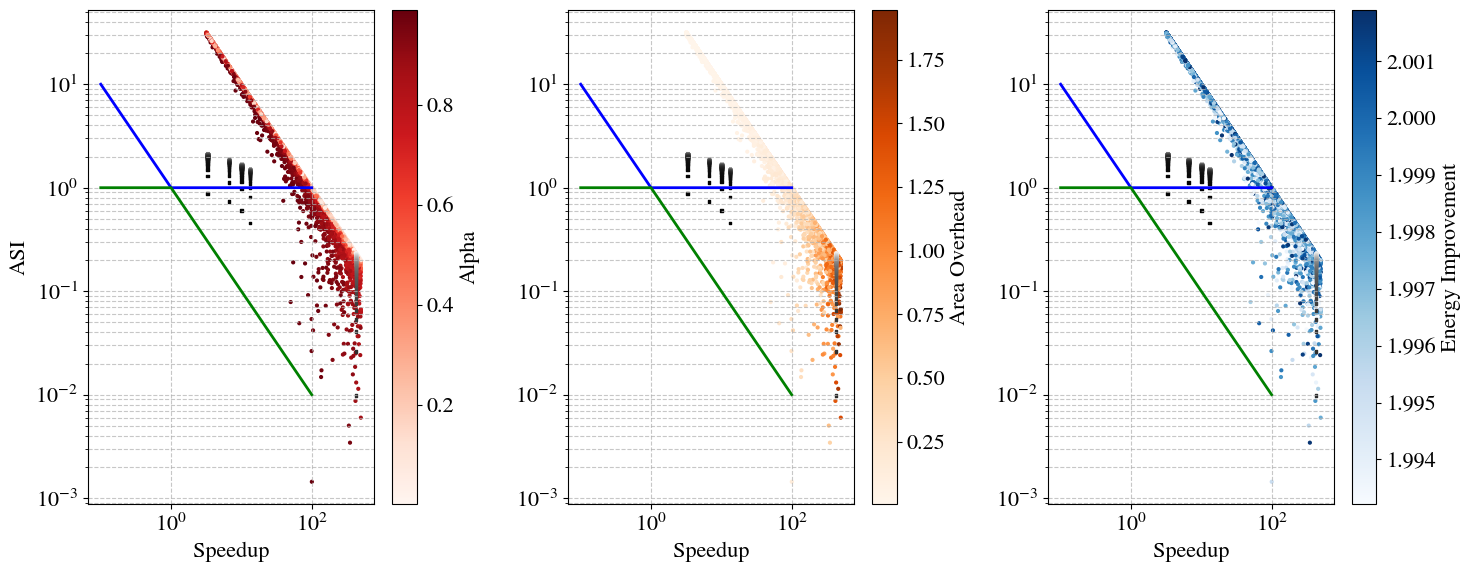

In [788]:
# ASI Framework separations
speedup_space = np.logspace(-1, 2, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xlabel('Speedup')
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(speedup,   asi_res,   c=alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

p = ax[1].scatter(speedup,   asi_res,   c=area_overhead,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')

p = ax[2].scatter(speedup,   asi_res,   c=np.log10(1/energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')


# Add our accelerator
for i in range(our_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[2].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')

p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[ref_point_soa],   np.maximum(soa_asi_res[:,ref_point_soa],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[ref_point_soa],   np.maximum(soa_asi_res[:,ref_point_soa],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[2].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[ref_point_soa],   np.maximum(soa_asi_res[:,ref_point_soa],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
# Add legend
fig.tight_layout()
plt.show()


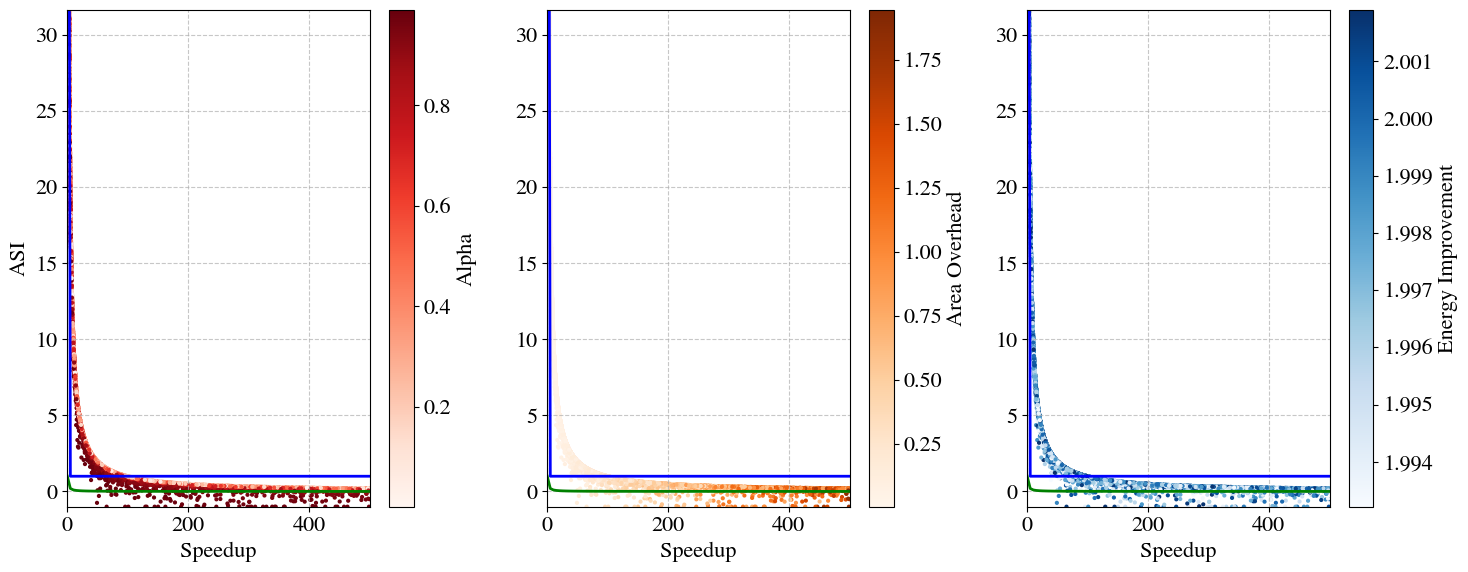

In [789]:
# ASI Framework separations
speedup_space = np.linspace(0.01, np.max(speedup), 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xlabel('Speedup')
    this_ax.set_ylim([-1,np.max(asi_res)])
    this_ax.set_xlim([0,np.max(speedup)])
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(speedup,   np.maximum(asi_res,-1),   c=alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

p = ax[1].scatter(speedup,   np.maximum(asi_res,-1),   c=area_overhead,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')

p = ax[2].scatter(speedup,   np.maximum(asi_res,-1),   c=np.log10(1/energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')

# Add legend
fig.tight_layout()
plt.show()


In [726]:

alpha_star = asi_critical_alpha(area_ratio=area_ratio, power_ratio=power_ratio, speedup=speedup)
region     = asi_classify(asi=asi_res, speedup=speedup)


valid_a_star = alpha_star[~np.isnan(alpha_star)]
region_counts = {r: (region == r).mean() for r in ['strong', 'weak', 'unsust']}

print("Alpha-independent region breakdown (hardware uncertainty only):")
for r, label in [('strong', 'Strongly sustainable (wins on area AND energy)'),
                  ('weak', 'Weakly sustainable (trade-off, alpha decides)'),
                  ('unsust', 'Unsustainable (loses on area AND energy)')]:
    print(f"  {label:55s}: {region_counts[r]*100:5.1f}%")

Alpha-independent region breakdown (hardware uncertainty only):
  Strongly sustainable (wins on area AND energy)         :  67.3%
  Weakly sustainable (trade-off, alpha decides)          :  30.8%
  Unsustainable (loses on area AND energy)               :   1.9%


In [727]:
inputs = {
    'Area overhead frac': area_overhead,
    'Speedup': speedup,
    'Energy Eff. Improv': 1/energy_ratio,
    'Power ratio': power_ratio,
    'Alpha': alpha,
}

sensitivities = {}
for name, x in inputs.items():
    rho, _ = stats.spearmanr(x, asi_res)
    sensitivities[name] = rho

print("Sensitivity of NCF_ratio to each input (Spearman rho):")
for name, rho in sorted(sensitivities.items(), key=lambda kv: -(kv[1])):
    print(f"  {name:25s}: {rho:+.3f}")

Sensitivity of NCF_ratio to each input (Spearman rho):
  Energy Eff. Improv       : -0.001
  Alpha                    : -0.084
  Area overhead frac       : -0.972
  Speedup                  : -0.994
  Power ratio              : -0.994


Text(0.5, 1.0, 'Sensitivity ranking')

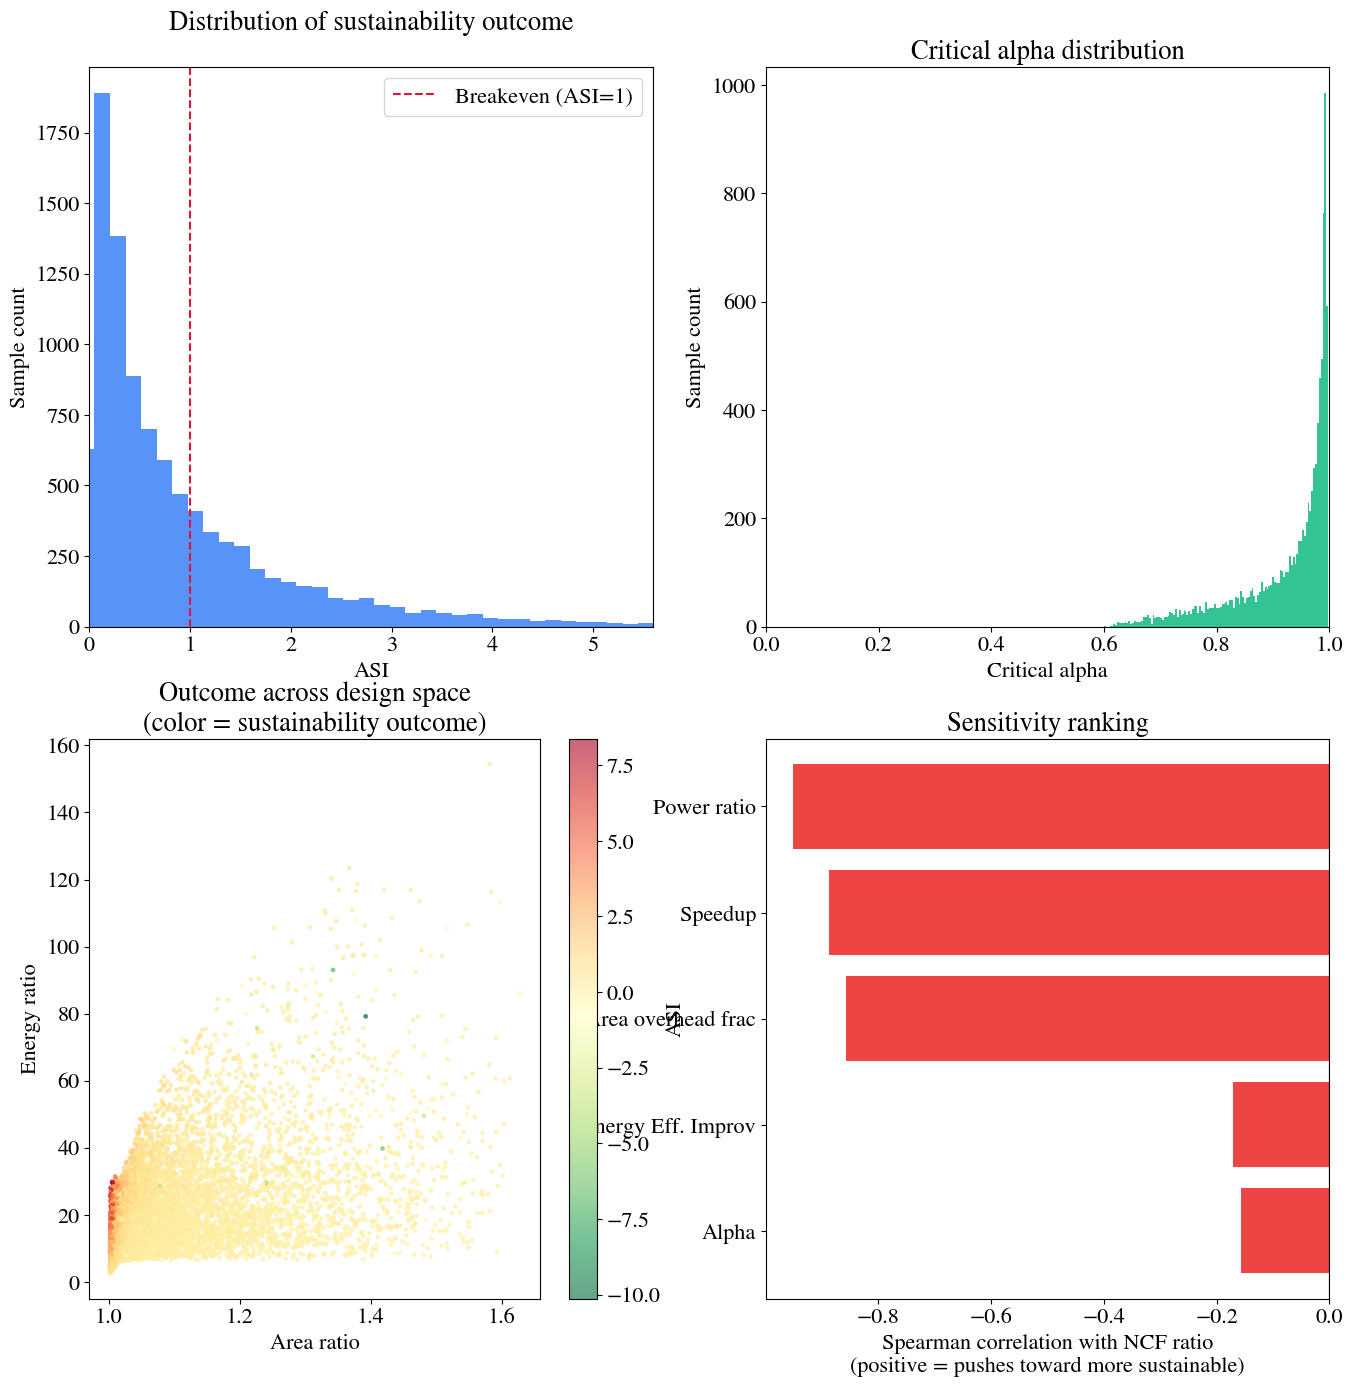

In [593]:

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# (a) NCF ratio distribution
ax = axes[0, 0]
ax.hist(asi_res, bins=120, color='#3b82f6', alpha=0.85, edgecolor='none')
ax.set_xlabel('ASI')
ax.set_ylabel('Sample count')
ax.set_title(f'Distribution of sustainability outcome\n')

ax.axvline(1.0, color='crimson', linestyle='--', linewidth=1.5,
           label='Breakeven (ASI=1)')
ax.legend()
ax.set_xlim(0, np.percentile(asi_res, 99.5))

# (b) Critical alpha* distribution
ax = axes[0, 1]
ax.hist(valid_a_star, bins=120, color='#10b981', alpha=0.85, edgecolor='none')
ax.set_xlabel('Critical alpha')
ax.set_ylabel('Sample count')
ax.set_title('Critical alpha distribution')
ax.set_xlim(0, 1)

# (c) Region map: area overhead vs speedup, colored by NCF ratio
ax = axes[1, 0]
sc = ax.scatter(area_ratio, 1/energy_ratio, c=asi_res,
                 cmap='RdYlGn_r', s=6, vmin=np.min(asi_res), vmax=np.max(asi_res), alpha=0.6)
plt.colorbar(sc, ax=ax, label='ASI')
ax.set_xlabel('Area ratio')
ax.set_ylabel('Energy ratio')
ax.set_title('Outcome across design space\n(color = sustainability outcome)')

# (d) Tornado / sensitivity chart
ax = axes[1, 1]
names_sorted = sorted(sensitivities, key=lambda k: abs(sensitivities[k]))
vals_sorted = [sensitivities[k] for k in names_sorted]
colors = ['#ef4444' if v < 0 else '#3b82f6' for v in vals_sorted]
ax.barh(names_sorted, vals_sorted, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman correlation with NCF ratio\n'
              '(positive = pushes toward more sustainable)')
ax.set_title('Sensitivity ranking')
